In [ ]:
import pandas as pd

from google.colab import files
uploaded = files.upload()

# Load dataset
df = pd.read_excel('/content/Online Retail Data Set.xlsx')

Saving Online Retail Data Set.xlsx to Online Retail Data Set.xlsx


In [ ]:
# Tampilkan info dasar
print("Dataset shape:", df.shape)
print(df.info())
print(df.head())

Dataset shape: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB
None
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER  

In [ ]:
# Menampilkan jumlah nilai null pada setiap kolom
print("Jumlah nilai null pada setiap kolom:\n")
print(df.isnull().sum())

Jumlah nilai null pada setiap kolom:

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [ ]:
# HANDLE NULL

# jumlah baris sebelum drop
print(f"Jumlah baris sebelum drop: {len(df)}")

# Drop baris yang memiliki nilai null pada kolom 'Description' dan 'CustomerID'
df_cleaned = df.dropna(subset=['Description', 'CustomerID'])

# jumlah baris setelah drop
print(f"Jumlah baris setelah drop: {len(df_cleaned)}")

# Cek apakah masih ada nilai null
print("\nSisa nilai null per kolom setelah pembersihan:")
print(df_cleaned.isnull().sum())

Jumlah baris sebelum drop: 541909
Jumlah baris setelah drop: 406829

Sisa nilai null per kolom setelah pembersihan:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [ ]:
#DUPLICATES

# baris yang duplikat
duplicates = df_cleaned[df_cleaned.duplicated()]
print(f"\nJumlah baris duplikat: {len(duplicates)}")

# contoh baris duplikat
print("\nContoh baris duplikat:")
print(duplicates.head())

# Hapus baris duplikat
df_cleaned_no_duplicates = df_cleaned.drop_duplicates()

# jumlah baris setelah duplikat dihapus
print(f"\nJumlah baris setelah hapus duplikat: {len(df_cleaned_no_duplicates)}")

# Cek kembali apakah masih ada duplikat
print("\nApakah masih ada duplikat?")
print(df_cleaned_no_duplicates.duplicated().sum())



Jumlah baris duplikat: 5225

Contoh baris duplikat:
    InvoiceNo StockCode                        Description  Quantity  \
517    536409     21866        UNION JACK FLAG LUGGAGE TAG         1   
527    536409     22866      HAND WARMER SCOTTY DOG DESIGN         1   
537    536409     22900    SET 2 TEA TOWELS I LOVE LONDON          1   
539    536409     22111       SCOTTIE DOG HOT WATER BOTTLE         1   
555    536412     22327  ROUND SNACK BOXES SET OF 4 SKULLS         1   

            InvoiceDate  UnitPrice  CustomerID         Country  
517 2010-12-01 11:45:00       1.25     17908.0  United Kingdom  
527 2010-12-01 11:45:00       2.10     17908.0  United Kingdom  
537 2010-12-01 11:45:00       2.95     17908.0  United Kingdom  
539 2010-12-01 11:45:00       4.95     17908.0  United Kingdom  
555 2010-12-01 11:49:00       2.95     17920.0  United Kingdom  

Jumlah baris setelah hapus duplikat: 401604

Apakah masih ada duplikat?
0


In [ ]:
# HANDLE OUTLIER

# setelah hapus duplicate
df_cleaned_no_duplicates = df_cleaned.drop_duplicates().copy()

# kolom TotalPrice
df_cleaned_no_duplicates['TotalPrice'] = df_cleaned_no_duplicates['Quantity'] * df_cleaned_no_duplicates['UnitPrice']

# Statistik deskriptif awal
print(df_cleaned_no_duplicates[['Quantity', 'UnitPrice', 'TotalPrice']].describe())


            Quantity      UnitPrice     TotalPrice
count  401604.000000  401604.000000  401604.000000
mean       12.183273       3.474064      20.613638
std       250.283037      69.764035     430.352218
min    -80995.000000       0.000000 -168469.600000
25%         2.000000       1.250000       4.250000
50%         5.000000       1.950000      11.700000
75%        12.000000       3.750000      19.800000
max     80995.000000   38970.000000  168469.600000


In [ ]:
# baris dengan Quantity < 0
df_cleaned_no_duplicates[df_cleaned_no_duplicates['Quantity'] < 0]

# baris dengan UnitPrice <= 0
df_cleaned_no_duplicates[df_cleaned_no_duplicates['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice


In [ ]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

# Deteksi outlier
outliers_quantity = detect_outliers_iqr(df_cleaned_no_duplicates, 'Quantity')
outliers_unitprice = detect_outliers_iqr(df_cleaned_no_duplicates, 'UnitPrice')
outliers_totalprice = detect_outliers_iqr(df_cleaned_no_duplicates, 'TotalPrice')

print(f"Outlier Quantity: {len(outliers_quantity)}")
print(f"Outlier UnitPrice: {len(outliers_unitprice)}")
print(f"Outlier TotalPrice: {len(outliers_totalprice)}")


Outlier Quantity: 26646
Outlier UnitPrice: 35802
Outlier TotalPrice: 32938


In [ ]:
# fungsi membersihkan outlier
def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]

# Terapkan untuk masing-masing kolom
df_clean = remove_outliers_iqr(df_cleaned_no_duplicates, 'Quantity')
df_clean = remove_outliers_iqr(df_clean, 'UnitPrice')
df_clean = remove_outliers_iqr(df_clean, 'TotalPrice')

# Hasil akhir
print("Jumlah data setelah hapus outlier:", df_clean.shape[0])


Jumlah data setelah hapus outlier: 325289


In [ ]:
import datetime as dt

#Buat fitur baru Recency, Frequency, Monetary.
# Tentukan tanggal referensi (1 hari setelah transaksi terakhir)
reference_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

# Hitung RFM
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
})

# Rename kolom
rfm.columns = ['Recency', 'Frequency', 'Monetary']

# Tampilkan 5 data teratas
print(rfm.head())


            Recency  Frequency  Monetary
CustomerID                              
12347.0           2          7   2783.37
12348.0         249          3     90.20
12349.0          19          1    939.75
12350.0         310          1    294.40
12352.0          36          8   1101.09


In [ ]:
# RFM Analysis (Recency, Frequency, Monetary)
# Membuat fungsi scoring R, F, M
def rfm_scoring(x, metric, ascending):
    return pd.qcut(x.rank(method='first', ascending=ascending), 5, labels=[5,4,3,2,1]).astype(int)

# Buat skor
rfm['R_Score'] = rfm_scoring(rfm['Recency'], metric='Recency', ascending=True)
rfm['F_Score'] = rfm_scoring(rfm['Frequency'], metric='Frequency', ascending=False)
rfm['M_Score'] = rfm_scoring(rfm['Monetary'], metric='Monetary', ascending=False)

# Buat kombinasi skor
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Lihat hasil
print(rfm.head())


            Recency  Frequency  Monetary  R_Score  F_Score  M_Score RFM_Score
CustomerID                                                                   
12347.0           2          7   2783.37        5        5        5       555
12348.0         249          3     90.20        1        4        1       141
12349.0          19          1    939.75        4        2        4       424
12350.0         310          1    294.40        1        2        3       123
12352.0          36          8   1101.09        3        5        4       354


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Clustering (KMeans)
# Ambil fitur
X = rfm[['Recency', 'Frequency', 'Monetary']]

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42) # 4 klaster
rfm['Cluster'] = kmeans.fit_predict(X_scaled)

# Lihat hasil klaster
print(rfm.head())


            Recency  Frequency  Monetary  R_Score  F_Score  M_Score RFM_Score  \
CustomerID                                                                      
12347.0           2          7   2783.37        5        5        5       555   
12348.0         249          3     90.20        1        4        1       141   
12349.0          19          1    939.75        4        2        4       424   
12350.0         310          1    294.40        1        2        3       123   
12352.0          36          8   1101.09        3        5        4       354   

            Cluster  
CustomerID           
12347.0           0  
12348.0           1  
12349.0           3  
12350.0           1  
12352.0           3  


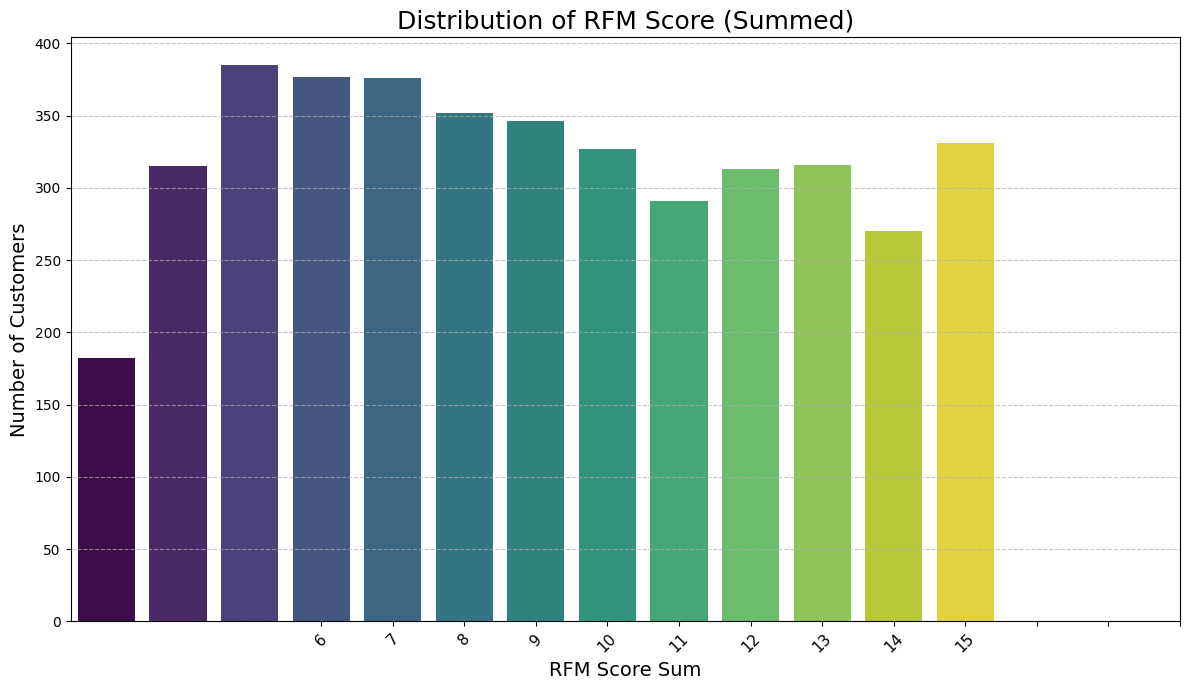

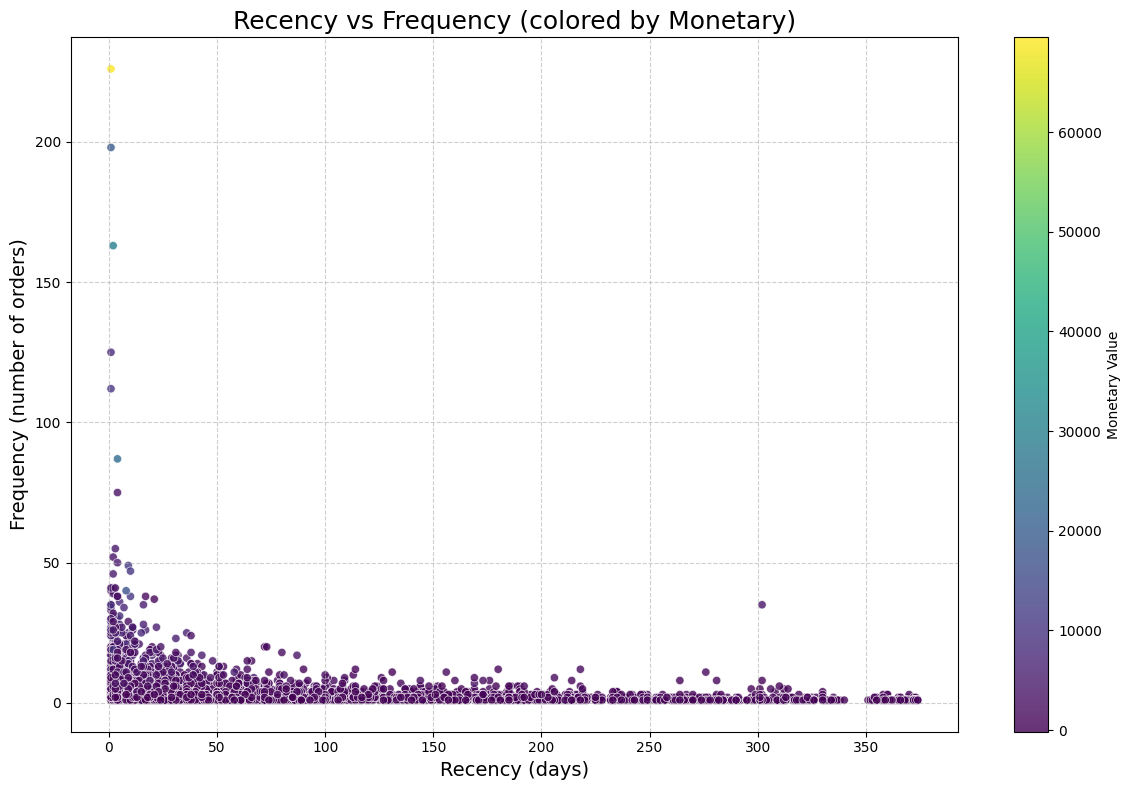

In [ ]:
# Import library
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan RFM_Score kamu dari gabungan 3 angka, kita ubah ke jumlah angka dulu
rfm['RFM_Score_Sum'] = rfm['RFM_Score'].astype(str).apply(lambda x: sum([int(digit) for digit in x]))

# Hitung jumlah customer per RFM Score SUM
rfm_score_count = rfm['RFM_Score_Sum'].value_counts().sort_index()

# Plot Histogram RFM Score Sum
plt.figure(figsize=(12,7))
sns.barplot(
    x=rfm_score_count.index,
    y=rfm_score_count.values,
    hue=rfm_score_count.index,  # Menambahkan hue sesuai x
    palette='viridis',
    dodge=False,
    legend=False  # Tidak perlu legend
)

plt.title('Distribution of RFM Score (Summed)', fontsize=18)
plt.xlabel('RFM Score Sum', fontsize=14)
plt.ylabel('Number of Customers', fontsize=14)
plt.xticks(
    ticks=range(rfm['RFM_Score_Sum'].min(), rfm['RFM_Score_Sum'].max() + 1),
    fontsize=11,
    rotation=45  # Sedikit miringkan biar tidak berhimpitan
)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Plot Scatter Recency vs Frequency colored by Monetary
plt.figure(figsize=(12,8))
scatter = plt.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    c=rfm['Monetary'],
    cmap='viridis',
    alpha=0.8,
    edgecolors='w',
    linewidths=0.5
)
plt.colorbar(scatter, label='Monetary Value')

plt.title('Recency vs Frequency (colored by Monetary)', fontsize=18)
plt.xlabel('Recency (days)', fontsize=14)
plt.ylabel('Frequency (number of orders)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# Customer Retention Analysis
# Hitung Repeat Purchase Rate.
# Total pelanggan
total_customers = rfm.shape[0]

# Pelanggan yang repeat beli (Frequency > 1)
repeat_customers = rfm[rfm['Frequency'] > 1].shape[0]

# Pelanggan yang hanya beli sekali (Frequency = 1)
one_time_customers = rfm[rfm['Frequency'] == 1].shape[0]

# Hitung Repeat Purchase Rate
repeat_purchase_rate = repeat_customers / total_customers

# Hitung Repeat Purchase Rate
oneTime_purchase_rate = one_time_customers / total_customers

# Tampilkan hasil
print(f"Total Customers             : {total_customers}")
print(f"Repeat Customers (>1x)      : {repeat_customers}")
print(f"One-time Customers (=1x)    : {one_time_customers}")
print(f"Repeat Purchase Rate        : {repeat_purchase_rate:.2%}")
print(f"One-time Purchase Rate      : {oneTime_purchase_rate:.2%}")



Total Customers             : 4181
Repeat Customers (>1x)      : 2813
One-time Customers (=1x)    : 1368
Repeat Purchase Rate        : 67.28%
One-time Purchase Rate      : 32.72%


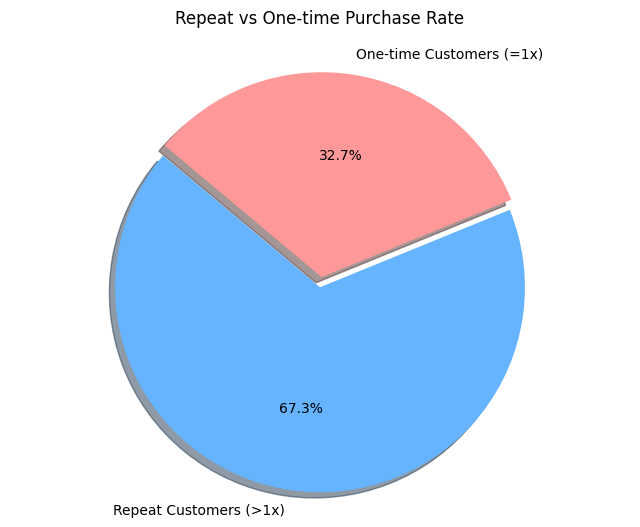

In [ ]:
#VISUALIZATION
# Repeate and one-time purchase
import matplotlib.pyplot as plt

# Data
labels = ['Repeat Customers (>1x)', 'One-time Customers (=1x)']
sizes = [2813, 1368]
colors = ['#66b3ff', '#ff9999']  # warna biru muda dan merah muda
explode = (0.05, 0)  # geser dikit bagian Repeat supaya menonjol

# Plot
plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Repeat vs One-time Purchase Rate', pad=20)
plt.axis('equal')  # supaya lingkarannya bulat
plt.show()


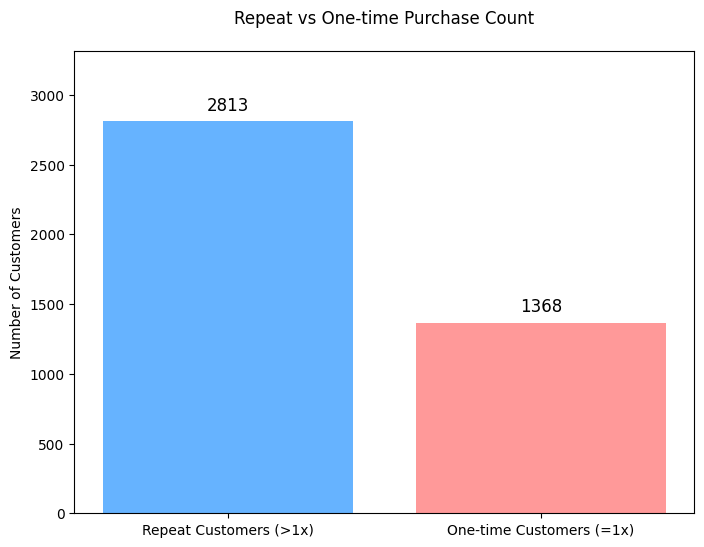

In [ ]:
import matplotlib.pyplot as plt

# Data
categories = ['Repeat Customers (>1x)', 'One-time Customers (=1x)']
counts = [2813, 1368]
colors = ['#66b3ff', '#ff9999']

# Plot
plt.figure(figsize=(8, 6))
bars = plt.bar(categories, counts, color=colors)

# Add title and labels
plt.title('Repeat vs One-time Purchase Count', pad=20)
plt.ylabel('Number of Customers')

# Add value labels di atas bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 50, int(yval), ha='center', va='bottom', fontsize=12)

plt.ylim(0, max(counts) + 500)  # Biar gak mepet atas
plt.show()


In [ ]:
import pandas as pd
import plotly.express as px

# Asumsi data sudah bersih dan ada 'InvoiceDate' dalam datetime format
import datetime

# Step 1: Ambil first purchase date tiap customer
first_purchase = df_cleaned.groupby('CustomerID')['InvoiceDate'].min().reset_index()
first_purchase.columns = ['CustomerID', 'FirstPurchaseDate']

# Step 2: Gabungkan dengan data terakhir pembelian
last_purchase = df_cleaned.groupby('CustomerID')['InvoiceDate'].max().reset_index()
last_purchase.columns = ['CustomerID', 'LastPurchaseDate']

# Step 3: Merge data first and last purchase
customer_life = pd.merge(first_purchase, last_purchase, on='CustomerID')

# Step 4: Definisikan status:
current_date = df_cleaned['InvoiceDate'].max()  # asumsi dataset terakhir
threshold_days = 90  # contoh: kalau lebih dari 90 hari tidak beli, dianggap churn

def label_status(row):
    if row['FirstPurchaseDate'] == row['LastPurchaseDate']:
        return 'New'
    elif (current_date - row['LastPurchaseDate']).days <= threshold_days:
        return 'Active'
    else:
        return 'Churn'

customer_life['Status'] = customer_life.apply(label_status, axis=1)

# Step 5: Hitung jumlah masing-masing
status_counts = customer_life['Status'].value_counts().reset_index()
status_counts.columns = ['Status', 'Count']

print(status_counts)


   Status  Count
0  Active   2352
1     New   1314
2   Churn    706


In [ ]:
#visualization funnel customers
fig = px.funnel(status_counts, x='Count', y='Status', color='Status',
                title='Customer Funnel: New → Active → Churn')
fig.show()

In [ ]:
import plotly.graph_objects as go

# Data untuk funnel
labels = ['New', 'Active', 'Churn']
values = [1314, 2352, 706]

# Buat Funnel Chart
fig = go.Funnel(
    y = labels,
    x = values,
    textinfo = "value+percent initial",
    marker = {"color": ["#00CC96", "#636EFA", "#EF553B"]}  # warna: new hijau, active biru, churn merah
)

# Layout
layout = go.Layout(
    title = {
        'text': 'Customer Funnel: New → Active → Churn',
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=24)
    },
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# Gabungkan figure dan layout
fig = go.Figure(data=[fig], layout=layout)

# Tampilkan chart
fig.show()


In [ ]:
import plotly.graph_objects as go

# Data funnel
labels = ['New', 'Active', 'Churn']
values = [1314, 2352, 706]

# Buat Vertical Funnel Chart
fig = go.Funnel(
    x = labels,             # Sekarang label di X-axis
    y = values,             # Nilai di Y-axis
    orientation = "v",       # 'v' berarti vertical
    textinfo = "value+percent initial",
    marker = {
        "color": ["#00CC96", "#636EFA", "#EF553B"]
    }
)

# Layout
layout = go.Layout(
    title = {
        'text': 'Customer Funnel (Vertical View)',
        'x': 0.5,
        'xanchor': 'center',
        'yanchor': 'top',
        'font': dict(size=24)
    },
    plot_bgcolor='white',
    paper_bgcolor='white'
)

# Gabungkan figure dan layout
fig = go.Figure(data=[fig], layout=layout)

# Tampilkan
fig.show()


In [ ]:
# Hitung Churn Rate dan Cohort Analysis.
# Hitung total customer
total_customers = status_counts['Count'].sum()

# Hitung customer churn
churn_customers = status_counts.loc[status_counts['Status'] == 'Churn', 'Count'].values[0]

# Hitung churn rate
churn_rate = churn_customers / total_customers * 100

print(f"Total Customers : {total_customers}")
print(f"Churn Customers : {churn_customers}")
print(f"Churn Rate      : {churn_rate:.2f}%")


Total Customers : 4372
Churn Customers : 706
Churn Rate      : 16.15%


In [ ]:
import pandas as pd

# Copy df_cleaned
df_cleaned = df_cleaned.copy()

# Pastikan InvoiceDate datetime
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])
df_cleaned['InvoiceMonth'] = df_cleaned['InvoiceDate'].dt.to_period('M')

# Cohort bulan pertama beli
cohort_data = (
    df_cleaned.groupby('CustomerID')['InvoiceMonth']
    .min()
    .reset_index()
)
cohort_data.rename(columns={'InvoiceMonth': 'InvoiceMonth_Cohort'}, inplace=True)

# Merge cohort ke df_cleaned
df_cleaned = pd.merge(df_cleaned, cohort_data, on='CustomerID', how='left')

# Debugging print
print(df_cleaned.columns)

# Fungsi hitung bulan ke berapa
def cohort_period(df):
    return (
        df['InvoiceMonth'].astype('period[M]').astype(int)
        - df['InvoiceMonth_Cohort'].astype('period[M]').astype(int)
    )

# Reset index
df_cleaned = df_cleaned.reset_index(drop=True)

# Tambahkan kolom CohortIndex
df_cleaned['CohortIndex'] = cohort_period(df_cleaned)

# Buat cohort count
cohort_counts = df_cleaned.groupby(['InvoiceMonth_Cohort', 'CohortIndex']).agg({'CustomerID': 'nunique'}).reset_index()

# Pivot
cohort_pivot = cohort_counts.pivot_table(
    index='InvoiceMonth_Cohort',
    columns='CohortIndex',
    values='CustomerID'
)

# Tampilkan
print(cohort_pivot)


Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'InvoiceMonth',
       'InvoiceMonth_Cohort'],
      dtype='object')
CohortIndex             0      1      2      3      4      5      6      7   \
InvoiceMonth_Cohort                                                           
2010-12              948.0  362.0  317.0  367.0  341.0  376.0  360.0  336.0   
2011-01              421.0  101.0  119.0  102.0  138.0  126.0  110.0  108.0   
2011-02              380.0   94.0   73.0  106.0  102.0   94.0   97.0  107.0   
2011-03              440.0   84.0  112.0   96.0  102.0   78.0  116.0  105.0   
2011-04              299.0   68.0   66.0   63.0   62.0   71.0   69.0   78.0   
2011-05              279.0   66.0   48.0   48.0   60.0   68.0   74.0   29.0   
2011-06              235.0   49.0   44.0   64.0   58.0   79.0   24.0    NaN   
2011-07              191.0   40.0   39.0   44.0   52.0   22.0    NaN    NaN   
2011-08              

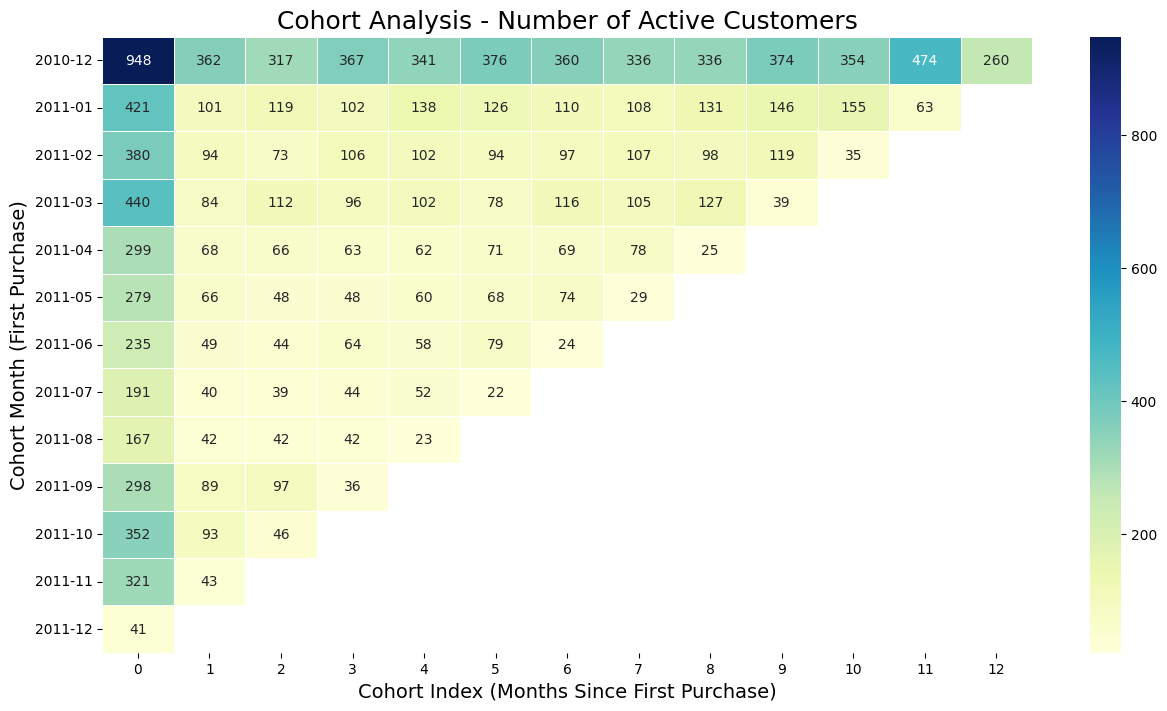

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set ukuran figure
plt.figure(figsize=(15, 8))

# Buat heatmap
sns.heatmap(
    cohort_pivot,
    annot=True,          # Tampilkan angka di setiap sel
    fmt='.0f',            # Format angka tanpa desimal
    cmap='YlGnBu',        # Warna: kuning-hijau-biru
    linewidths=0.5,       # Garis antar kotak
    linecolor='white'     # Warna garis antar kotak
)

# Tambahkan judul dan label sumbu
plt.title('Cohort Analysis - Number of Active Customers', fontsize=18)
plt.xlabel('Cohort Index (Months Since First Purchase)', fontsize=14)
plt.ylabel('Cohort Month (First Purchase)', fontsize=14)

# Tampilkan plot
plt.show()


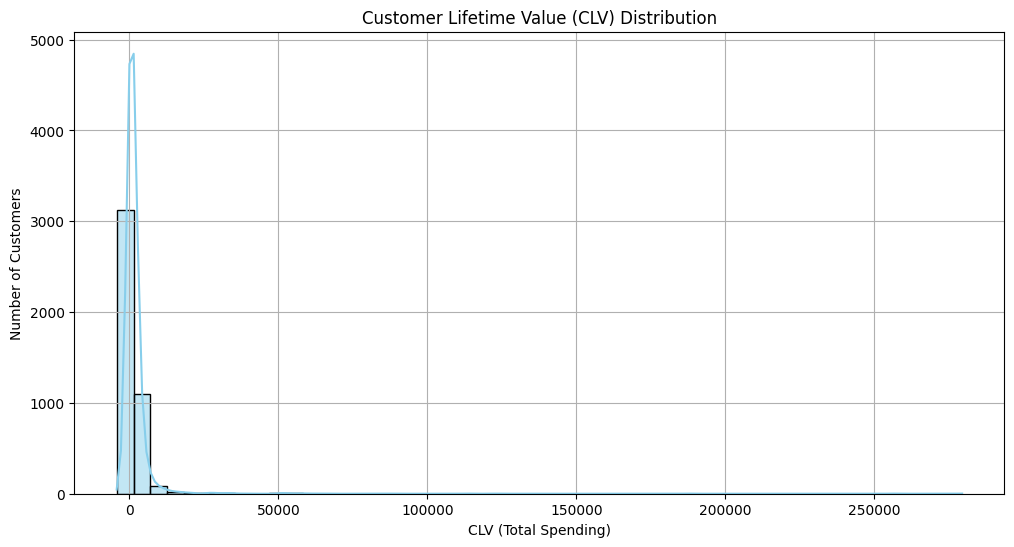

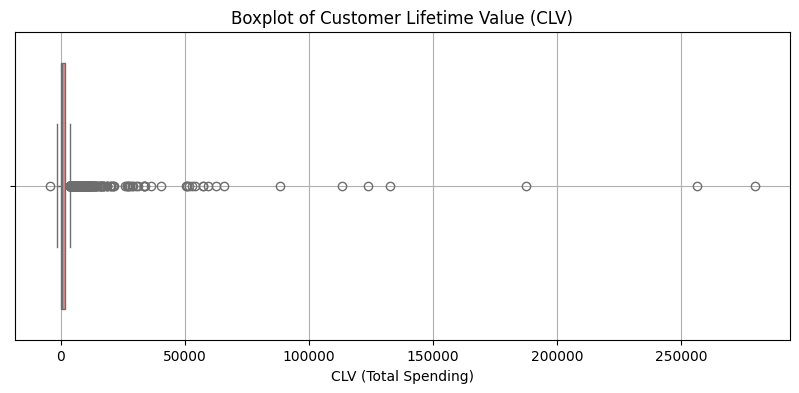

In [ ]:
# CLV Distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Anggap df_cleaned sudah tersedia ---

# Hitung CLV per Customer
df_cleaned['TotalPrice'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']
clv = df_cleaned.groupby('CustomerID')['TotalPrice'].sum().reset_index()
clv.rename(columns={'TotalPrice': 'CLV'}, inplace=True)

# Plot CLV Distribution
plt.figure(figsize=(12,6))
sns.histplot(clv['CLV'], bins=50, kde=True, color='skyblue')
plt.title('Customer Lifetime Value (CLV) Distribution')
plt.xlabel('CLV (Total Spending)')
plt.ylabel('Number of Customers')
plt.grid(True)
plt.show()

# Boxplot
plt.figure(figsize=(10,4))
sns.boxplot(x=clv['CLV'], color='lightcoral')
plt.title('Boxplot of Customer Lifetime Value (CLV)')
plt.xlabel('CLV (Total Spending)')
plt.grid(True)
plt.show()


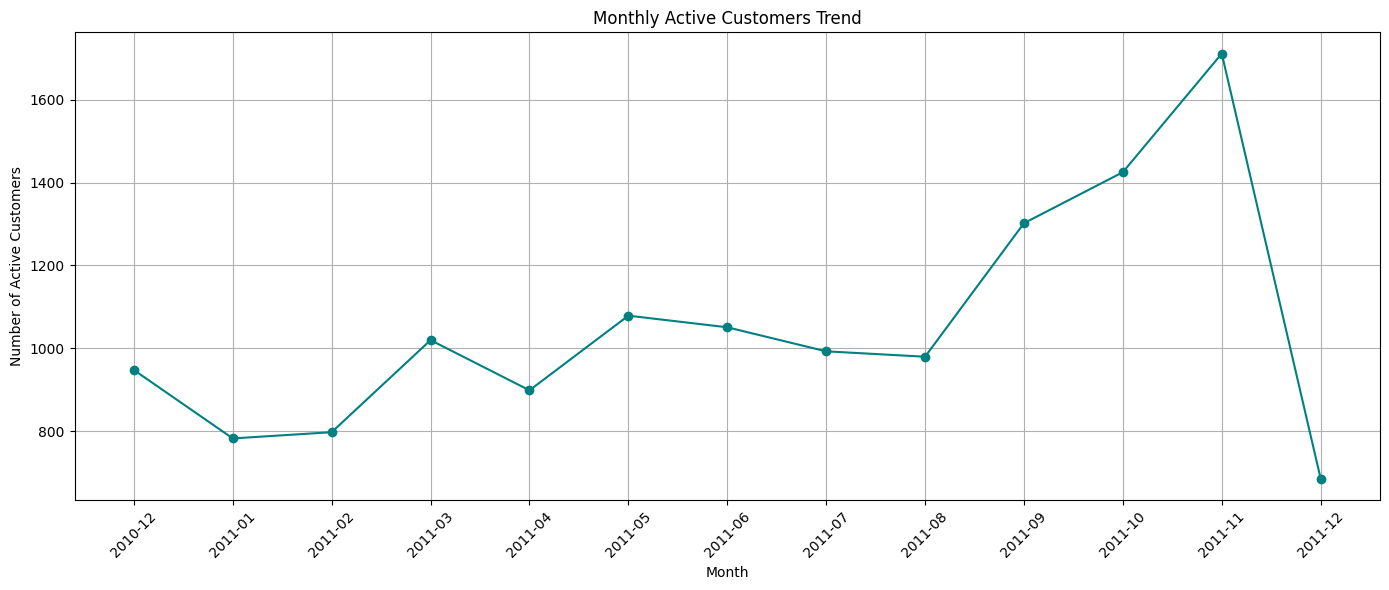

In [ ]:
# Monthly Active Customers Trend
import pandas as pd
import matplotlib.pyplot as plt

# --- Pastikan df_cleaned sudah ada dan InvoiceDate sudah datetime ---

# kolom InvoiceMonth
df_cleaned['InvoiceMonth'] = df_cleaned['InvoiceDate'].dt.to_period('M')

# Hitung jumlah unique CustomerID per InvoiceMonth
monthly_active = df_cleaned.groupby('InvoiceMonth')['CustomerID'].nunique().reset_index()
monthly_active['InvoiceMonth'] = monthly_active['InvoiceMonth'].astype(str)  # Supaya label di plot rapi

# Plot Monthly Active Customers
plt.figure(figsize=(14,6))
plt.plot(monthly_active['InvoiceMonth'], monthly_active['CustomerID'], marker='o', color='teal')
plt.title('Monthly Active Customers Trend')
plt.xlabel('Month')
plt.ylabel('Number of Active Customers')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


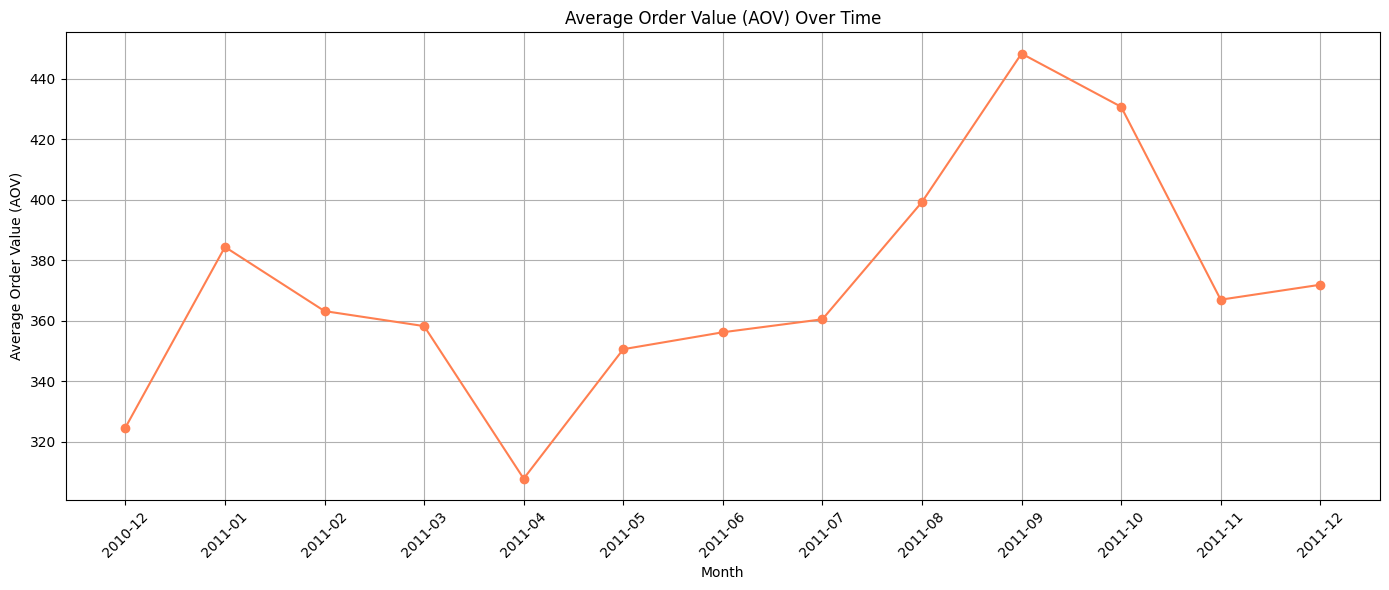

In [ ]:
# Average Order Value (AOV) Over Time
import pandas as pd
import matplotlib.pyplot as plt

df_cleaned['InvoiceMonth'] = df_cleaned['InvoiceDate'].dt.to_period('M')

# Hitung Revenue per Invoice
df_cleaned['Revenue'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

# Hitung Total Revenue & Jumlah Order per InvoiceMonth
monthly_revenue = df_cleaned.groupby('InvoiceMonth').agg({
    'Revenue': 'sum',
    'InvoiceNo': 'nunique'  # Setiap InvoiceNo dianggap satu order
}).reset_index()

# 4. Hitung AOV (Average Order Value)
monthly_revenue['AOV'] = monthly_revenue['Revenue'] / monthly_revenue['InvoiceNo']
monthly_revenue['InvoiceMonth'] = monthly_revenue['InvoiceMonth'].astype(str)  # Supaya label rapi

# 5. Plot AOV Over Time
plt.figure(figsize=(14,6))
plt.plot(monthly_revenue['InvoiceMonth'], monthly_revenue['AOV'], marker='o', color='coral')
plt.title('Average Order Value (AOV) Over Time')
plt.xlabel('Month')
plt.ylabel('Average Order Value (AOV)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


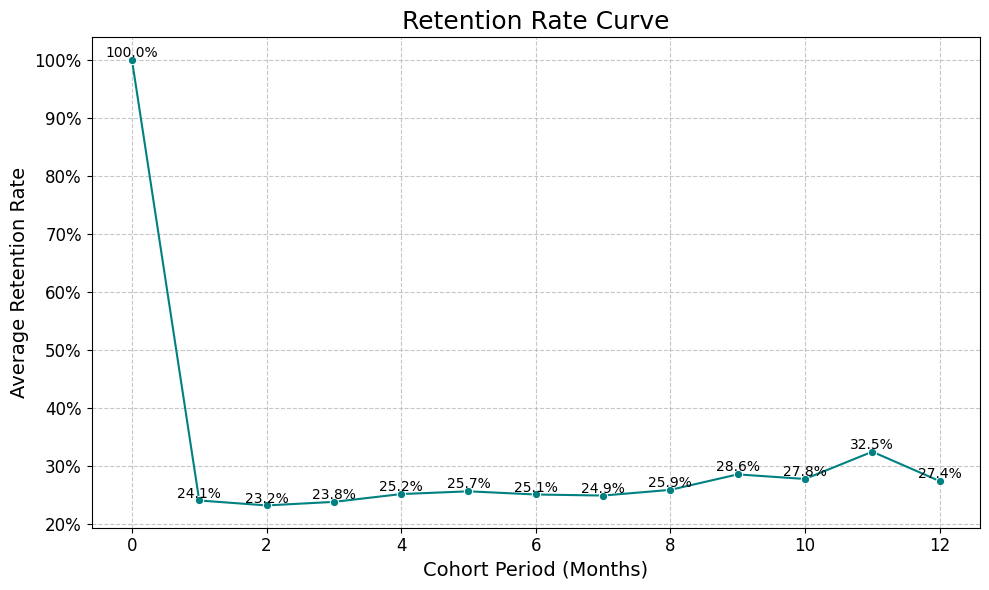

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# Copy cohort_pivot untuk membuat retention rate
retention_rate = cohort_pivot.copy()

# Bagi semua nilai dengan cohort bulan ke-0 (yaitu bulan pertama join) untuk dapat persentase retention
retention_rate = retention_rate.divide(retention_rate[0], axis=0)

# Hitung rata-rata retention tiap bulan cohort
avg_retention = retention_rate.mean()

# Plot Retention Rate Curve
plt.figure(figsize=(10,6))
sns.lineplot(
    x=avg_retention.index,
    y=avg_retention.values,
    marker='o',
    color='teal'
)

plt.title('Retention Rate Curve', fontsize=18)
plt.xlabel('Cohort Period (Months)', fontsize=14)
plt.ylabel('Average Retention Rate', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Format y-axis ke bentuk persen
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:.0%}'.format(y)))

plt.grid(True, linestyle='--', alpha=0.7)

# label persentase di tiap titik
for x, y in zip(avg_retention.index, avg_retention.values):
    plt.text(x, y+0.005, f'{y:.1%}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()


In [ ]:
# Menyimpan semua DataFrame ke csv
df_cleaned.to_csv('df_cleaned.csv', index=False)
status_counts.to_csv('status_count.csv')
rfm.to_csv('rfm.csv')
cohort_pivot.to_csv('cohort_pivot.csv')
retention_rate.to_csv('retention_rate.csv')
avg_retention.to_csv('avg_retention.csv')
